# Step 2: Subcluster and Color Cells

This step further clusters cells into subtypes and adds a colorscheme for each.

## Setup and Imports

In [1]:
# Imports
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from pathlib import Path
import anndata as ad
import matplotlib as mpl
import matplotlib.cm as cm
from scipy.stats import gaussian_kde
from matplotlib.patches import Polygon

In [2]:
# Reproducibility settings
sc.settings.verbosity = 3
np.random.seed(26)

In [3]:
# Path config
indir = '/Users/yyj/Doc/1_dod_dec25/processed_data/' #indir = '/path/to/xenium/raw_data'
outdir = '/Users/yyj/Doc/1_dod_dec25/processed_data/' #outdir = '/path/to/integrated/processed_data'
figdir = '/Users/yyj/Doc/1_dod_dec25/figures/' #outdir = '/path/to/integrated/figures'

In [4]:
# Figure settings
plt.rcParams['savefig.transparent'] = True
plt.rcParams['savefig.dpi'] = 600
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams["font.family"] = "Helvetica"
mpl.rcParams['font.size'] = 6 # 5-7
sc.settings.figdir = figdir

## Helper functions

In [5]:
# Define a function to create a unique ID based on barcode + sample (if needed)
def make_unique_id(ad):
    # Check if 'sample' column exists
    if 'sample' not in ad.obs.columns:
        print("Error: 'sample' column missing.")
        return
    
    # Create new unique index: "Barcode_SampleID"
    # Clean the existing index to remove any previous appended "-1", "-2" if necessary
    clean_index = ad.obs.index.str.split('-').str[0] 
    ad.obs.index = clean_index + '_' + ad.obs['sample'].astype(str)
    
    # Verify uniqueness
    if not ad.obs.index.is_unique:
        print("Warning: Indices are still not unique! Appending numbers.")
        ad.obs_names_make_unique()
    else:
        print("Success: Indices are unique and sample-specific.")

## Load data

In [ ]:
adata = sc.read_h5ad(indir + 'xenium_integrated.h5ad')
make_unique_id(adata)

In [ ]:
adata_T = sc.read_h5ad(indir + 'T_subclustered.h5ad')
make_unique_id(adata_T)

In [ ]:
adata_B = sc.read_h5ad(indir + 'B_subclustered.h5ad')
make_unique_id(adata_B)

In [ ]:
adata_neuro = sc.read_h5ad(indir + 'Neuroblast_subclustered.h5ad')
make_unique_id(adata_neuro)

In [ ]:
adata_macro = sc.read_h5ad(indir + 'Macrophage_subclustered.h5ad')
make_unique_id(adata_macro)

## Label T cells

In [ ]:
cluster_col = 'leiden_T_0.5'

In [ ]:
sc.pl.violin(adata_T, ['CD3E'], groupby = cluster_col, size = 0)

In [ ]:
sc.pl.umap(adata_T, color=cluster_col, show=True) # Cluster 8 is contamination and needs to be removed

In [ ]:
# Remove contaminated cluster 8
print(f"Before filtering: {adata_T.n_obs} cells")
adata_T = adata_T[adata_T.obs[cluster_col] != "8"].copy()
print(f"After removing cluster 8: {adata_T.n_obs} cells")

In [ ]:
# Create dotplot
# Define the genes to plot
genes_to_plot = [
    'CD8A', 'CD4', 'GZMH', 'KLRD1', 'IL7R', 'TCF7', 'SELL', 'CCR7','MKI67',
    'FOXP3', 'CTLA4', 'TIGIT', 'TRGC2'
]

# Visualize the dotplot
sc.pl.dotplot(
    adata_T,
    genes_to_plot,
    groupby=cluster_col,
    standard_scale='var',  # Scales expression 0-1 for easier comparison
    cmap='YlOrRd',           # Color map
    title='T cell Subtypes Marker Expression'
)

In [ ]:
# Label T cell subclusters based on marker genes
T_subtypes = {
    0: 'Cytotoxic T',
    1: 'Naive/CM T',
    2: 'γδT',
    3: 'Naive/CM T',
    4: 'Naive/CM T',
    5: 'Naive/CM T',
    6: 'Cytotoxic T',
    7: 'γδT',
    9: 'Treg',
    10: 'Proliferating T'
}

# Assign colors to subtypes
T_colors = {
    'Proliferating T': '#d7191c',
    'Cytotoxic T': '#fdae61',
    'γδT': '#ffffbf',
    'Naive/CM T': '#abd9e9',
    'Treg': '#2c7bb6',
}


In [ ]:
# Add subtype to adata_T
subtype_map = {str(k): v for k, v in T_subtypes.items()}
adata_T.obs['T_subtype'] = adata_T.obs['leiden_T_0.5'].astype(str).map(subtype_map)

In [ ]:
# Add T cell subtype labels to adata
adata.obs['T_subtype'] = 'NA'
adata.obs.loc[adata_T.obs.index, 'T_subtype'] = adata_T.obs['T_subtype']
print("Before filtering:")
print(adata.obs['T_subtype'].value_counts())

In [ ]:
# Get contaminated T cells (celltype == T but T_subtype == NA)
print(f"\nBefore filtering: {adata.n_obs} cells")

mask_to_remove = (adata.obs['celltype'] == 'T') & (adata.obs['T_subtype'] == 'NA')
n_to_remove = mask_to_remove.sum()
print(f"Removing {n_to_remove} contaminated T cells")

In [ ]:
# Filter out contaminated T cells
adata = adata[~mask_to_remove].copy()

print(f"After filtering: {adata.n_obs} cells")
print("\nAfter filtering:")
print(adata.obs['T_subtype'].value_counts())

In [ ]:
# Save labeled T cell data
adata_T.write_h5ad(outdir + 'T_labeled.h5ad', compression='gzip')

## Label B cells

In [ ]:
cluster_col = 'leiden_B_0.3'

In [ ]:
sc.pl.umap(adata_B, color=cluster_col, show=True)

In [ ]:
# Create dotplot
# Define the genes to plot
genes_to_plot = [
    'CD19' , 'MS4A1', 'CD86', 'IGHM', 'CCR7', 'CD27', 'CD38', 
    'MKI67', 'FLT3', 'IDO1', 'IL3RA', 'IRF8'
]

# Visualize the dotplot
sc.pl.dotplot(
    adata_B,
    genes_to_plot,
    groupby=cluster_col,
    standard_scale='var',  # Scales expression 0-1 for easier comparison
    cmap='YlOrRd',           # Color map
    title='B cell Subtypes Marker Expression',
    save='_B_subtype_dotplot.pdf'
)

In [ ]:
# Remove contaminated cluster 5
print(f"Before filtering: {adata_B.n_obs} cells")
adata_B = adata_B[adata_B.obs[cluster_col] != "5"].copy()
print(f"After removing cluster 5: {adata_B.n_obs} cells")

In [ ]:
# Label B cell subclusters based on marker genes
B_subtypes = {
    0: 'Naive B',
    1: 'Naive B',
    2: 'Plasma',
    3: 'pDC',
    4: 'Activated B',
    6: 'cDC',
    7: 'Proliferating memory B'
}

# Assign colors to subtypes
B_colors = {
    'Naive B': '#d73027',
    'Activated B': '#fc8d59',
    'Plasma': '#fee090',
    'pDC': '#e0f3f8',
    'cDC': '#91bfdb',
    'Proliferating memory B': '#4575b4'
}


In [ ]:
subtype_map = {str(k): v for k, v in B_subtypes.items()}
adata_B.obs['B_subtype'] = adata_B.obs['leiden_B_0.3'].astype(str).map(subtype_map)

In [ ]:
# Add subtype to adata_B
adata.obs['B_subtype'] = 'NA'
adata.obs.loc[adata_B.obs.index, 'B_subtype'] = adata_B.obs['B_subtype']
print("Before filtering:")
print(adata.obs['B_subtype'].value_counts())

In [ ]:
# Get contaminated B cells (celltype == B but B_subtype == NA)
print(f"\nBefore filtering: {adata.n_obs} cells")

mask_to_remove = (adata.obs['celltype'] == 'B') & (adata.obs['B_subtype'] == 'NA')
n_to_remove = mask_to_remove.sum()
print(f"Removing {n_to_remove} contaminated B cells")

In [ ]:
# Filter out contaminated B cells
adata = adata[~mask_to_remove].copy()

print(f"After filtering: {adata.n_obs} cells")
print("\nAfter filtering:")
print(adata.obs['B_subtype'].value_counts())

In [ ]:
# Save labeled B cell data
adata_B.write_h5ad(outdir + 'B_labeled.h5ad', compression='gzip')

## Label macrophages

In [ ]:
cluster_col = 'leiden_Macrophage_0.3'

In [ ]:
sc.pl.umap(adata_macro, color=cluster_col, show=True)

In [ ]:
# Create dotplot
# Define the genes to plot, based on Yu et al. (2025) https://doi.org/10.1038/s41588-025-02158-6
genes_to_plot = [
    'C1QC', 'CD68', # C1QC
    'CCL4', # CCL4
    'F13A1', 'RNASE1', # F13A1
    'HS3ST2', 'CYP27A1', # HS3ST2
    'IL18', 'IRF8', # Pro-inflammatory
    'TOP2A', 'MKI67', # MKI67
    'VCAN', # VCAN
    ]

# Visualize the dotplot
sc.pl.dotplot(
    adata_macro,
    genes_to_plot,
    groupby=cluster_col,
    standard_scale='var', 
    cmap='YlOrRd',
    title='Macrophage Subtypes Marker Expression'
)

In [ ]:
# Label macrophage subclusters based on marker genes
macro_subtypes = {
    0: 'Pro-inflammatory Mφ',
    1: 'Proliferating Mφ',
    2: 'HS3ST2 Mφ',
    3: 'Proliferating Mφ',
    4: 'VCAN Mφ',
    5: 'C1QC Mφ', # tissue resident
    6: 'F13A1 Mφ', # tissue resident
    7: 'Pro-inflammatory Mφ',
    8: 'CCL4 Mφ'
}

# Assign colors to subtypes
macro_colors = {
    'Pro-inflammatory Mφ': '#d73027',
    'Proliferating Mφ': '#fc8d59',
    'VCAN Mφ': '#fee090',
    'F13A1 Mφ': '#ffffbf',
    'HS3ST2 Mφ': '#e0f3f8',
    'C1QC Mφ': '#91bfdb',
    'CCL4 Mφ': '#4575b4',
    }


In [ ]:
subtype_map = {str(k): v for k, v in macro_subtypes.items()}
adata_macro.obs['macro_subtype'] = adata_macro.obs['leiden_Macrophage_0.3'].astype(str).map(subtype_map)

In [ ]:
# Add subtype labels to adata_macro
adata.obs['macro_subtype'] = 'NA'
adata.obs.loc[adata_macro.obs.index, 'macro_subtype'] = adata_macro.obs['macro_subtype']
print(adata.obs['macro_subtype'].value_counts())

In [ ]:
# Save labeled macrophage data
adata_macro.write_h5ad(outdir + 'Macrophage_labeled.h5ad', compression='gzip')

## Neuroblasts

In [ ]:
cluster_col = 'leiden_Neuroblast_0.5'

In [ ]:
sc.pl.umap(adata_neuro, color=cluster_col, show=True)

In [ ]:
# Create dotplot
# Define the genes to plot, based on Yu et al. (2025) https://doi.org/10.1038/s41588-025-02158-6
# genes_to_plot = [
    'PHOX2B', 'HAND2', # general
    'KCNQ3', 'FMN1', 'PPP2R2C', # calcium
    'TH', 'DBH', 'GCH1', # dopaminergic
    'MKI67', 'TOP2A', 'EZH2', 'MKI67', # proliferating
    'BEX1', 'NEFL', # Differentiated
    'MYCN', 'COL1A1', 'COL4A1' # MYCN

    ]

# Visualize the dotplot
sc.pl.dotplot(
    adata_neuro,
    genes_to_plot,
    groupby=cluster_col,
    standard_scale='var',  # Scales expression 0-1 for easier comparison
    cmap='YlOrRd',           # Color map
    title='Neuroblast Subtypes Marker Expression'
)

In [ ]:
# Label neuroblast subclusters based on marker genes
neuro_subtypes = {
    0: 'ADRN_Dopaminergic',     # Baseline/dopaminergic
    1: 'ADRN_Proliferating',    # Proliferating
    2: 'ADRN_Dopaminergic',     # Dopaminergic
    3: 'ADRN_Dopaminergic',     # Dopaminergic
    4: 'ADRN_Calcium',          # Calcium
    5: 'ADRN_Proliferating',    # Proliferating
    6: 'Differentiated',        
    7: 'ADRN_Calcium',       ##########  
    8: 'MYCN',       # MYCN
    9: 'MYCN',       # MYCN
}

# Assign colors to subtypes
neuro_colors = {
    'ADRN_Dopaminergic': '#d7191c',
    'ADRN_Proliferating': '#fdae61',
    'ADRN_Calcium': '#ffffbf',
    'Differentiated': '#abd9e9',
    'MYCN': '#2c7bb6',
}

In [ ]:
subtype_map = {str(k): v for k, v in neuro_subtypes.items()}
adata_neuro.obs['neuro_subtype'] = adata_neuro.obs['leiden_Neuroblast_0.5'].astype(str).map(subtype_map)

In [ ]:
# Add neuroblast subtype labels to adata_neuro
adata.obs['neuro_subtype'] = 'NA'
adata.obs.loc[adata_neuro.obs.index, 'neuro_subtype'] = adata_neuro.obs['neuro_subtype']
print(adata.obs['neuro_subtype'].value_counts())

In [ ]:
# Save labeled neuroblast data
adata_neuro.write_h5ad(outdir + 'Neuroblast_labeled.h5ad', compression='gzip')

## Add metadata and make plots for adata

In [5]:
adata = sc.read_h5ad(indir + 'xenium_integrated_labeled.h5ad')

In [ ]:
# Initialize celltypes_all with the broad celltype
adata.obs['celltypes_all'] = adata.obs['celltype'].astype(str)

# Update with subtypes where available
# Iterate through your subtype columns
for col in ['T_subtype', 'B_subtype', 'macro_subtype', 'neuro_subtype']:
    if col in adata.obs.columns:
        mask = (adata.obs[col] != 'NA')
        
        # Overwrite the celltype_all for these cells
        adata.obs.loc[mask, 'celltypes_all'] = adata.obs.loc[mask, col]

print(adata.obs['celltypes_all'].value_counts())

In [ ]:
# Assign colors to celltypes
color_map = {
    'Endothelial': '#d73027',
    'Fibroblast': '#f46d43',
    'Schwann': '#fdae61',
    'Neuroblast': '#fee090',
    'Macrophage': '#e0f3f8',
    'B': '#abd9e9',
    'T': '#74add1',
}

# Define celltype order
order_celltype = ['Endothelial', 'Fibroblast', 'Schwann', 'Neuroblast', 'Macrophage', 'B', 'T']

# Set celltype as categorical with celltype order
adata.obs['celltype'] = adata.obs['celltype'].astype('category')
adata.obs['celltype'] = adata.obs['celltype'].cat.reorder_categories(order_celltype)

# Assign colors in the same order as celltype categories
adata.uns['celltype_colors'] = [color_map[cat] for cat in adata.obs['celltype'].cat.categories]

In [ ]:
# Create sample mapping dictionary
sample_mapping = {
    'PAZNRG_0DPHBP': 'PAZNRG_PT',
    'PAZNRG_ODNNSP': 'PAZNRG_DX',
    'PBADJC_0DNOML': 'PBADJC_PT',
    'PBADJC_ODNOLY': 'PBADJC_DX',
    'PBBCHF_ODNNA3': 'PBBCHF_PT',
    'PBBCHF_ODNNBG': 'PBBCHF_DX',
}

# Apply the mapping
adata.obs['sample'] = adata.obs['sample'].astype(str).replace(sample_mapping)

# Convert back to categorical
adata.obs['sample'] = adata.obs['sample'].astype('category')

# Verify the changes
print(adata.obs['sample'].unique())

In [ ]:
# Add patient and timepoint metadata
adata.obs['patient'] = adata.obs['sample'].str.replace(r'_(DX|PT)$', '', regex=True)
adata.obs['timepoint'] = adata.obs['sample'].str.extract(r'_(DX|PT)$')[0]

In [ ]:
# Make colored UMAP
fig, ax = plt.subplots(figsize=(10/2.54, 8/2.54))  # cm -> inches

sc.pl.umap(
    adata,
    color="celltype",
    frameon=False,
    legend_loc=None,
    size=2,
    ax=ax,
    show=False
)

fig.savefig(
    f"{figdir}umap_celltype.png",
    dpi=600,
    bbox_inches="tight",
    transparent=True
)

plt.show()

In [ ]:
# Save source data
umap_df = pd.DataFrame({
    "id": adata.obs_names,
    "umap1": adata.obsm["X_umap"][:, 0],
    "umap2": adata.obsm["X_umap"][:, 1],
    "celltype": adata.obs["celltype"].values
})

for ct, subdf in umap_df.groupby("celltype"):
    ct_safe = str(ct).replace("/", "_").replace(" ", "_")

    if ct == "Neuroblast":
        # split into two roughly equal parts
        mid = len(subdf) // 2
        subdf.iloc[:mid].to_csv(
            f"{outdir}umap_celltype_source_data_{ct_safe}_part1.csv",
            index=False
        )
        subdf.iloc[mid:].to_csv(
            f"{outdir}umap_celltype_source_data_{ct_safe}_part2.csv",
            index=False
        )
    else:
        subdf.to_csv(f"{outdir}umap_celltype_source_data_{ct_safe}.csv", index=False)

/var/folders/b3/wsvv1lxx3xgdznfjpwc1z68h0000gn/T/ipykernel_79941/3039864456.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for ct, subdf in umap_df.groupby("celltype"):


In [ ]:
# Make colored UMAP split by timepoint
for tp in ["DX", "PT"]:
    adata_tp = adata[adata.obs["timepoint"] == tp].copy()

    fig, ax = plt.subplots(figsize=(10/2.54, 8/2.54))

    sc.pl.umap(
        adata_tp,
        color="celltype",
        frameon=False,
        legend_loc=None,
        size=2,
        ax=ax,
        show=False
    )

    fig.savefig(
        f"{figdir}umap_celltype_{tp}.png",
        dpi=600,
        bbox_inches="tight",
        transparent=True
    )

    plt.show()
    plt.close(fig)

In [ ]:
# Make density plots
# Get coordinates of all cells
X_all = adata.obsm["X_umap"][:, 0]
Y_all = adata.obsm["X_umap"][:, 1]

# Make grid (expanded bounds to prevent contour truncation at edges)
xmin, xmax = X_all.min(), X_all.max()
ymin, ymax = Y_all.min(), Y_all.max()

xrange = xmax - xmin
yrange = ymax - ymin
xpad = 0.10 * xrange
ypad = 0.10 * yrange

xmin_g, xmax_g = xmin - xpad, xmax + xpad
ymin_g, ymax_g = ymin - ypad, ymax + ypad

# Keep full-resolution grid
xx, yy = np.mgrid[xmin_g:xmax_g:200j, ymin_g:ymax_g:200j]
grid = np.vstack([xx.ravel(), yy.ravel()])

# Global KDE using all cells
kde_all = gaussian_kde(np.vstack([X_all, Y_all]))
zz_all = kde_all(grid).reshape(xx.shape)
levels = np.linspace(zz_all.min(), zz_all.max(), 6)

In [ ]:
# Visualize UMAP density contours (no downsampling)
for tp in adata.obs["timepoint"].unique():
    adata_tp = adata[adata.obs["timepoint"] == tp]

    # use all cells in this timepoint
    x = adata_tp.obsm["X_umap"][:, 0]
    y = adata_tp.obsm["X_umap"][:, 1]

    kde_tp = gaussian_kde(np.vstack([x, y]))
    zz_tp = kde_tp(grid).reshape(xx.shape)

    plt.figure(figsize=(6, 4))
    plt.contour(xx, yy, zz_tp, levels=levels, colors="black", linewidths=1)
    plt.title(f"UMAP density contours {tp} (n={adata_tp.n_obs})")
    plt.axis("off")
    plt.savefig(f"{figdir}_umap_density_contours_{tp}.pdf", bbox_inches="tight")
    plt.show()

In [ ]:
# Calculate celltype composition
comp = pd.crosstab(adata.obs['sample'], adata.obs['celltype'])
comp_prop = comp.div(comp.sum(axis=1), axis=0)

sample_order = [
    'PBBKFP_PT',
    'PBBKFP_DX',
    'PBADJC_PT',
    'PBADJC_DX',
    'PAZWZN_PT',
    'PAZWZN_DX',
    'PBBCHF_PT',
    'PBBCHF_DX',
    'PAZNRG_PT',
    'PAZNRG_DX', 

]

# Reorder
comp_prop = comp_prop.reindex(sample_order)
comp = comp.reindex(sample_order)

In [ ]:
# Get order of samples
order = comp_prop.index.tolist()

# Make dataframe for stacked barplot of celltype composition
meta = adata.obs[["sample", "patient", "timepoint"]].drop_duplicates().set_index("sample")

# Precompute segment positions
seg = {}
for i, sample in enumerate(order):
    cum = 0
    seg[sample] = {}
    for celltype in comp_prop.columns:
        w = comp_prop.loc[sample, celltype]
        seg[sample][celltype] = (cum, cum + w)
        cum += w

In [ ]:
# Figure settings
fig, ax = plt.subplots(figsize=(15.5/2.54, 8.5/2.54))
comp_prop.loc[order].plot(kind="barh", stacked=True, color=color_map, ax=ax)

bar_h = 0.5

# Draw alluvial ribbons between DX and PT for each patient
for patient in meta["patient"].unique():
    samples = [s for s in order if (s in meta.index and meta.loc[s, "patient"] == patient)]

    # pick DX and PT in the order they appear in the ORIGINAL plot
    dx = [s for s in samples if meta.loc[s, "timepoint"] == "DX"]
    pt = [s for s in samples if meta.loc[s, "timepoint"] == "PT"]
    if len(dx) == 0 or len(pt) == 0:
        continue

    s_dx, s_pt = dx[0], pt[0]
    y_dx = order.index(s_dx)
    y_pt = order.index(s_pt)

    # Determine upper/lower by y index in this plot
    if y_dx < y_pt:
        s_upper, y_upper = s_dx, y_dx
        s_lower, y_lower = s_pt, y_pt
    else:
        s_upper, y_upper = s_pt, y_pt
        s_lower, y_lower = s_dx, y_dx

    # INNER edges toward each other:
    # bottom of upper bar -> top of lower bar
    y_start = y_upper + bar_h / 2.0
    y_end   = y_lower - bar_h / 2.0

    for celltype in comp_prop.columns:
        x1a, x1b = seg[s_upper][celltype]
        x2a, x2b = seg[s_lower][celltype]

        poly = Polygon(
            [(x1a, y_start), (x1b, y_start), (x2b, y_end), (x2a, y_end)],
            closed=True,
            facecolor=color_map[celltype],
            alpha=0.5,
            edgecolor="none",
            zorder=0
        )
        ax.add_patch(poly)

# Add counts + percentages
for i, sample in enumerate(order):
    cumulative_width = 0
    for celltype in comp_prop.columns:
        width = comp_prop.loc[sample, celltype]
        count = comp.loc[sample, celltype]

        if width > 0.02:
            text_x = cumulative_width + width / 2
            text_y = i
            label_text = f"{int(count)}\n({width:.2f})"
            ax.text(
                text_x, text_y, label_text,
                ha="center", va="center",
                fontsize=5, color="#000000", rotation=0
            )
        cumulative_width += width

# Styling and save
ax.set_xlabel("Proportion")
ax.set_ylabel("Sample")
ax.set_title("Cell Type Composition per Sample (Integrated Xenium)")
if ax.legend_:
    ax.legend_.remove()
ax.grid(False)
ax.set_frame_on(False)
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.savefig(
    f"{figdir}celltype_composition_barplot_alluvial.pdf",
    format="pdf", bbox_inches="tight"
)
plt.show()

In [ ]:
# Save composition tables
comp.to_csv(f"{outdir}fig2a_celltype_composition_counts.csv", index=True)
comp_prop.to_csv(f"{outdir}fig2a_celltype_composition_proportions.csv", index=True)

In [6]:
# Make dotplot for main celltypes
# Set genes to plot
genes_to_plot = [
    'VWF', 'PTPRB',      # Endothelial
    'PDGFRA', 'DCN',     # Fibroblast
    'S100B', 'CDH19',    # Schwann
    'PHOX2B', 'SRRM4',   # Neuroblast
    'ITGAX', 'MS4A6A',   # Macrophage
    'IGHM', 'CD22',      # B cells
    'CD3E', 'CD96'       # T cells
]

/var/folders/b3/wsvv1lxx3xgdznfjpwc1z68h0000gn/T/ipykernel_79941/781426111.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


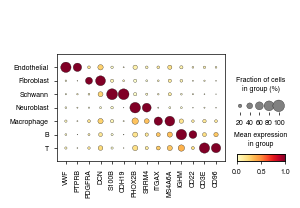

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


In [9]:
# Make dotplot
dp = sc.pl.dotplot(
    adata,
    genes_to_plot,
    groupby='celltype',
    cmap='YlOrRd',
    return_fig=True,
    show=False,
    standard_scale='var',
)

dp = dp.style(
    smallest_dot=0.01,
    largest_dot=70,
)

# Access axes and style borders
ax_dict = dp.get_axes()

# Make ticks thinner
for _, ax in ax_dict.items():
    if ax is None:
        continue
    ax.tick_params(axis="both", which="both", width=0.5, length=2)

# Main panel border
main_ax = ax_dict.get("mainplot_ax", None)
if main_ax is not None:
    for spine in main_ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.5)
        spine.set_color("#000000")

# Color legend bar border
cax = ax_dict.get("color_legend_ax", None)
if cax is not None:
    for spine in cax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.5)
        spine.set_color("#000000")


# Styling and save
fig = dp.fig
fig.set_size_inches(7.5/2.54, 5/2.54, forward=True)
fig.tight_layout()
fig.canvas.draw()

display(fig)

fig.savefig(f"{figdir}celltype_dotplot.pdf", bbox_inches="tight")
plt.close(fig)

In [38]:
pd.Series(adata.var_names, name="var_name").to_csv(
    f"{outdir}xenium_panel.csv",
    index=False
)

## Make figures for T cells

In [22]:
adata_T = sc.read_h5ad(outdir + 'T_labeled.h5ad')

In [23]:
# Create mapping dictionary
sample_mapping = {
    'PAZNRG_0DPHBP': 'PAZNRG_PT',
    'PAZNRG_ODNNSP': 'PAZNRG_DX',
    'PBADJC_0DNOML': 'PBADJC_PT',
    'PBADJC_ODNOLY': 'PBADJC_DX',
    'PBBCHF_ODNNA3': 'PBBCHF_PT',
    'PBBCHF_ODNNBG': 'PBBCHF_DX',
}

# Apply the mapping
adata_T.obs['sample'] = adata_T.obs['sample'].astype(str).replace(sample_mapping)

# Convert back to categorical if needed
adata_T.obs['sample'] = adata_T.obs['sample'].astype('category')

# Verify the changes
print(adata_T.obs['sample'].unique())

['PAZNRG_PT', 'PAZNRG_DX', 'PAZWZN_DX', 'PAZWZN_PT', 'PBADJC_PT', 'PBADJC_DX', 'PBBCHF_PT', 'PBBCHF_DX', 'PBBKFP_DX', 'PBBKFP_PT']
Categories (10, object): ['PAZNRG_DX', 'PAZNRG_PT', 'PAZWZN_DX', 'PAZWZN_PT', ..., 'PBBCHF_DX', 'PBBCHF_PT', 'PBBKFP_DX', 'PBBKFP_PT']


In [24]:
# Add patient and timepoint metadata
adata_T.obs['patient'] = adata_T.obs['sample'].str.replace(r'_(DX|PT)$', '', regex=True)
adata_T.obs['timepoint'] = adata_T.obs['sample'].str.extract(r'_(DX|PT)$')[0]

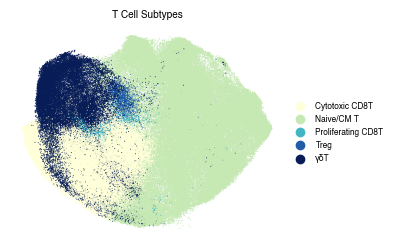

In [25]:
# Make colored UMAP
fig, ax = plt.subplots(figsize=(9/2.54, 7/2.54))

sc.pl.umap(
    adata_T,
    color='T_subtype',
    palette='YlGnBu',
    title='T Cell Subtypes',
    frameon=False,
    legend_loc='right margin',
    size=2,
    ax=ax,
    show=False
)

fig.savefig(
    f"{figdir}umap_T_subtype.png",
    dpi=600,
    bbox_inches="tight",
    transparent=True
)

plt.show()

In [ ]:
# Make colored UMAP split by timepoint

for tp in ["DX", "PT"]:
    adata_tp = adata_T[adata_T.obs["timepoint"] == tp].copy()

    fig, ax = plt.subplots(figsize=(9/2.54, 7/2.54))

    sc.pl.umap(
        adata_tp,
        color="T_subtype",
        palette="YlGnBu",
        title=f"T Cell Subtypes ({tp})",
        frameon=False,
        legend_loc=None,
        size=2,
        ax=ax,
        show=False
    )

    fig.savefig(
        f"{figdir}umap_T_subtype_{tp}.png",
        dpi=600,
        bbox_inches="tight",
        transparent=True
    )

    plt.show()
    plt.close(fig)

In [ ]:
# Make density plots
# Get coordinates of all cells
X_all = adata_T.obsm["X_umap"][:, 0]
Y_all = adata_T.obsm["X_umap"][:, 1]

# Make grid (expanded bounds to prevent contour truncation at edges)
xmin, xmax = X_all.min(), X_all.max()
ymin, ymax = Y_all.min(), Y_all.max()

xrange = xmax - xmin
yrange = ymax - ymin
xpad = 0.10 * xrange
ypad = 0.10 * yrange

xmin_g, xmax_g = xmin - xpad, xmax + xpad
ymin_g, ymax_g = ymin - ypad, ymax + ypad

# Keep full-resolution grid
xx, yy = np.mgrid[xmin_g:xmax_g:200j, ymin_g:ymax_g:200j]
grid = np.vstack([xx.ravel(), yy.ravel()])

# Global KDE using all cells
kde_all = gaussian_kde(np.vstack([X_all, Y_all]))
zz_all = kde_all(grid).reshape(xx.shape)
levels = np.linspace(zz_all.min(), zz_all.max(), 6)

In [ ]:
# Visualize UMAP density contours (no downsampling)
for tp in adata_T.obs["timepoint"].unique():
    adata_tp = adata_T[adata_T.obs["timepoint"] == tp]

    # use all cells in this timepoint
    x = adata_tp.obsm["X_umap"][:, 0]
    y = adata_tp.obsm["X_umap"][:, 1]

    kde_tp = gaussian_kde(np.vstack([x, y]))
    zz_tp = kde_tp(grid).reshape(xx.shape)

    plt.figure(figsize=(6, 4))
    plt.contour(xx, yy, zz_tp, levels=levels, colors="black", linewidths=1)
    plt.title(f"UMAP density contours {tp} (n={adata_tp.n_obs})")
    plt.axis("off")
    plt.savefig(f"{figdir}_umap_density_contours_T_{tp}.pdf", bbox_inches="tight")
    plt.show()

In [29]:
# Make dotplot for T cells
# Set genes to plot
genes_to_plot = [
    'CD8A', 'CD4', 'TRGC2',
    'GZMH', 'KLRD1',
    'IL7R', 'TCF7', 'SELL', 'CCR7',
    'MKI67',
    'FOXP3', 'CTLA4', 'TIGIT', 
]

/var/folders/b3/wsvv1lxx3xgdznfjpwc1z68h0000gn/T/ipykernel_79941/2418607070.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


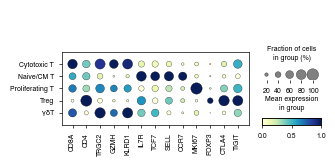

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


In [31]:
# Make dotplot
dp = sc.pl.dotplot(
    adata_T,
    genes_to_plot,
    groupby='T_subtype',
    cmap='YlGnBu',
    return_fig=True,
    show=False,
    standard_scale='var',
)

dp = dp.style(
    smallest_dot=0.01,
    largest_dot=70,
)

# Access axes and style borders
ax_dict = dp.get_axes()

# Make ticks thinner
for _, ax in ax_dict.items():
    if ax is None:
        continue
    ax.tick_params(axis="both", which="both", width=0.5, length=2)

# Main panel border
main_ax = ax_dict.get("mainplot_ax", None)
if main_ax is not None:
    for spine in main_ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.5)
        spine.set_color("#000000")

# Color legend bar border
cax = ax_dict.get("color_legend_ax", None)
if cax is not None:
    for spine in cax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.5)
        spine.set_color("#000000")


# Styling and save
fig = dp.fig
fig.set_size_inches(8.5/2.54, 3.8/2.54, forward=True)
fig.tight_layout()
fig.canvas.draw()

display(fig)

fig.savefig(f"{figdir}celltype_dotplot_T.pdf", bbox_inches="tight")
plt.close(fig)

In [33]:
# Make proportion dotplot
# Build dataframe
df = (
    adata_T.obs
    .groupby(["timepoint", "T_subtype"])
    .size()
    .reset_index(name="count")
)
df["prop"] = df.groupby("timepoint")["count"].transform(lambda x: x / x.sum())

# flip order (PT on top, DX below)
df["timepoint"] = pd.Categorical(df["timepoint"], categories=["PT", "DX"], ordered=True)

/var/folders/b3/wsvv1lxx3xgdznfjpwc1z68h0000gn/T/ipykernel_79941/2567113081.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["timepoint", "T_subtype"])
/var/folders/b3/wsvv1lxx3xgdznfjpwc1z68h0000gn/T/ipykernel_79941/2567113081.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df["prop"] = df.groupby("timepoint")["count"].transform(lambda x: x / x.sum())


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


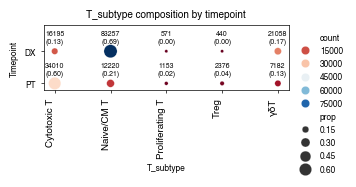

In [34]:
# Draw figure
fig, ax = plt.subplots(figsize=(9/2.54, 4.6/2.54))

ax = sns.scatterplot(
    data=df,
    x="T_subtype", y="timepoint",
    size="prop", sizes=(5, 90),
    hue="count", palette="RdBu",
    ax=ax
)

# y positions
ypos = {cat: i for i, cat in enumerate(df["timepoint"].cat.categories)}

# Label dots
for _, row in df.iterrows():
    y = ypos[row["timepoint"]] + 0.2
    x = row["T_subtype"]
    label = f"{int(row['count'])}\n({row['prop']:.2f})"
    ax.text(
        x, y, label,
        ha="center", va="bottom",
        fontsize=5, color="black", clip_on=False
    )

ax.set_yticks(list(ypos.values()))
ax.set_yticklabels(list(ypos.keys()))
ax.set_title("T_subtype composition by timepoint")
ax.set_xlabel("T_subtype")
ax.set_ylabel("Timepoint")

plt.setp(ax.get_xticklabels(), rotation=90, ha="right")
ax.tick_params(axis="x", labelsize=7)
ax.tick_params(axis="both", width=0.5, length=2)  # thinner tick lines

# Spacing settings
ax.set_ylim(-0.2, 1.8)

# Legend setting
ax.legend(
    bbox_to_anchor=(1, 1),
    loc="upper left",
    frameon=False
)

# Line width settings
for spine in ax.spines.values():
    spine.set_linewidth(0.5)

fig.tight_layout()
fig.savefig(f"{figdir}dotplot_count_timepoint_T.pdf", bbox_inches="tight")
plt.show()

In [ ]:
# Save composition table
df.to_csv(f"{outdir}fig2d_T_composition_counts.csv", index=True)

In [ ]:
# Visualize T cell proportion across timepoints for each patient
tbl = (
    adata_T.obs
    .groupby(["sample", "timepoint", "T_subtype"])
    .size()
    .reset_index(name="count")
)

tbl["prop"] = tbl.groupby(["sample", "timepoint"])["count"].transform(lambda x: x / x.sum())

prop_wide = (
    tbl.pivot_table(
        index=["sample", "timepoint"],
        columns="T_subtype",
        values="prop",
        fill_value=0
    )
    .reset_index()
)

prop_wide

/var/folders/b3/wsvv1lxx3xgdznfjpwc1z68h0000gn/T/ipykernel_61744/2584674029.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["sample", "timepoint", "T_subtype"])
/var/folders/b3/wsvv1lxx3xgdznfjpwc1z68h0000gn/T/ipykernel_61744/2584674029.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tbl["prop"] = tbl.groupby(["sample", "timepoint"])["count"].transform(lambda x: x / x.sum())
/var/folders/b3/wsvv1lxx3xgdznfjpwc1z68h0000gn/T/ipykernel_61744/2584674029.py:12: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify 

T_subtype,sample,timepoint,Cytotoxic CD8T,Naive/CM T,Proliferating CD8T,Treg,γδT
0,PAZNRG_DX,DX,0.019269,0.932829,0.002566,0.001351,0.043985
1,PAZNRG_PT,PT,0.120736,0.746673,0.010646,0.012824,0.109122
2,PAZWZN_DX,DX,0.002165,0.987013,0.000000,0.000000,0.010823
3,PAZWZN_PT,PT,0.232451,0.705409,0.021864,0.000000,0.040276
4,PBADJC_DX,DX,0.021886,0.963760,0.001090,0.000663,0.012601
5,PBADJC_PT,PT,0.144751,0.728526,0.006363,0.005832,0.114528
6,PBBCHF_DX,DX,0.369160,0.125160,0.007240,0.008469,0.489971
7,PBBCHF_PT,PT,0.688293,0.108040,0.020772,0.048517,0.134378
8,PBBKFP_DX,DX,0.022638,0.953250,0.005381,0.001682,0.017050
9,PBBKFP_PT,PT,0.108562,0.820565,0.036460,0.000819,0.033593


In [21]:
# Save proportion table
prop_wide.to_csv(f"{outdir}fig2d_T_composition_per_timepoint.csv", index=True)

In [ ]:
# Save source data for adata_T
umap_df = pd.DataFrame({
    "id": adata_T.obs_names,
    "umap1": adata_T.obsm["X_umap"][:, 0],
    "umap2": adata_T.obsm["X_umap"][:, 1],
    "T_subtype": adata_T.obs["T_subtype"].values
})

umap_df.to_csv(f"{outdir}umap_Tsubtype_source_data_all.csv", index=False)

## Make figures for B cells

In [45]:
adata_B = sc.read_h5ad(outdir + 'B_labeled.h5ad')

In [46]:
# Create mapping dictionary
sample_mapping = {
    'PAZNRG_0DPHBP': 'PAZNRG_PT',
    'PAZNRG_ODNNSP': 'PAZNRG_DX',
    'PBADJC_0DNOML': 'PBADJC_PT',
    'PBADJC_ODNOLY': 'PBADJC_DX',
    'PBBCHF_ODNNA3': 'PBBCHF_PT',
    'PBBCHF_ODNNBG': 'PBBCHF_DX',
}

# Apply the mapping
adata_B.obs['sample'] = adata_B.obs['sample'].astype(str).replace(sample_mapping)

# Convert back to categorical if needed
adata_B.obs['sample'] = adata_B.obs['sample'].astype('category')

# Verify the changes
print(adata_B.obs['sample'].unique())

['PAZNRG_PT', 'PAZNRG_DX', 'PAZWZN_DX', 'PAZWZN_PT', 'PBADJC_PT', 'PBADJC_DX', 'PBBCHF_PT', 'PBBCHF_DX', 'PBBKFP_DX', 'PBBKFP_PT']
Categories (10, object): ['PAZNRG_DX', 'PAZNRG_PT', 'PAZWZN_DX', 'PAZWZN_PT', ..., 'PBBCHF_DX', 'PBBCHF_PT', 'PBBKFP_DX', 'PBBKFP_PT']


In [47]:
# Add patient and timepoint metadata
adata_B.obs['patient'] = adata_B.obs['sample'].str.replace(r'_(DX|PT)$', '', regex=True)
adata_B.obs['timepoint'] = adata_B.obs['sample'].str.extract(r'_(DX|PT)$')[0]

In [ ]:
# Make colored UMAP
fig, ax = plt.subplots(figsize=(9/2.54, 7/2.54))

sc.pl.umap(
    adata_B,
    color='B_subtype',
    palette='YlGnBu',
    title='B Cell Subtypes',
    frameon=False,
    legend_loc='right margin',
    size=2,
    ax=ax,
    show=False
)

fig.savefig(
    f"{figdir}umap_B_subtype.png",
    dpi=600,
    bbox_inches="tight",
    transparent=True
)

plt.show()


In [ ]:
# Make colored UMAP split by timepoint
for tp in ["DX", "PT"]:
    adata_tp = adata_B[adata_B.obs["timepoint"] == tp].copy()

    fig, ax = plt.subplots(figsize=(9/2.54, 7/2.54))

    sc.pl.umap(
        adata_tp,
        color="B_subtype",
        palette="YlGnBu",
        title=f"B Cell Subtypes ({tp})",
        frameon=False,
        legend_loc=None,
        size=2,
        ax=ax,
        show=False
    )

    fig.savefig(
        f"{figdir}umap_B_subtype_{tp}.png",
        dpi=600,
        bbox_inches="tight",
        transparent=True
    )

    plt.show()
    plt.close(fig)


In [ ]:
# Make density plots
# Get coordinates of all cells
X_all = adata_B.obsm["X_umap"][:, 0]
Y_all = adata_B.obsm["X_umap"][:, 1]

# Make grid (expanded bounds to prevent contour truncation at edges)
xmin, xmax = X_all.min(), X_all.max()
ymin, ymax = Y_all.min(), Y_all.max()

xrange = xmax - xmin
yrange = ymax - ymin
xpad = 0.10 * xrange
ypad = 0.10 * yrange

xmin_g, xmax_g = xmin - xpad, xmax + xpad
ymin_g, ymax_g = ymin - ypad, ymax + ypad

# Keep full-resolution grid
xx, yy = np.mgrid[xmin_g:xmax_g:200j, ymin_g:ymax_g:200j]
grid = np.vstack([xx.ravel(), yy.ravel()])

# Global KDE using all cells
kde_all = gaussian_kde(np.vstack([X_all, Y_all]))
zz_all = kde_all(grid).reshape(xx.shape)
levels = np.linspace(zz_all.min(), zz_all.max(), 6)


In [ ]:
# Visualize UMAP density contours (no downsampling)
for tp in adata_B.obs["timepoint"].unique():
    adata_tp = adata_B[adata_B.obs["timepoint"] == tp]

    # use all cells in this timepoint
    x = adata_tp.obsm["X_umap"][:, 0]
    y = adata_tp.obsm["X_umap"][:, 1]

    kde_tp = gaussian_kde(np.vstack([x, y]))
    zz_tp = kde_tp(grid).reshape(xx.shape)

    plt.figure(figsize=(6, 4))
    plt.contour(xx, yy, zz_tp, levels=levels, colors="black", linewidths=1)
    plt.title(f"UMAP density contours {tp} (n={adata_tp.n_obs})")
    plt.axis("off")
    plt.savefig(f"{figdir}_umap_density_contours_B_{tp}.pdf", bbox_inches="tight")
    plt.show()


In [ ]:
# Make dotplot for B cells
# Set genes to plot
genes_to_plot = [
    'CD19' , 'MS4A1', 'CD86', 'IGHM', 'CCR7', 'CD27', 'CD38', 
    'MKI67', 'FLT3', 'IDO1', 'IL3RA', 'IRF8'
]

In [ ]:
# Make dotplot
dp = sc.pl.dotplot(
    adata_B,
    genes_to_plot,
    groupby='B_subtype',
    cmap='YlGnBu',
    return_fig=True,
    show=False,
    standard_scale='var',
)

dp = dp.style(
    smallest_dot=0.01,
    largest_dot=70,
)

# Access axes and style borders
ax_dict = dp.get_axes()

# Make ticks thinner
for _, ax in ax_dict.items():
    if ax is None:
        continue
    ax.tick_params(axis="both", which="both", width=0.5, length=2)

# Main panel border
main_ax = ax_dict.get("mainplot_ax", None)
if main_ax is not None:
    for spine in main_ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.5)
        spine.set_color("#000000")

# Color legend bar border
cax = ax_dict.get("color_legend_ax", None)
if cax is not None:
    for spine in cax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.5)
        spine.set_color("#000000")


# Styling and save
fig = dp.fig
fig.set_size_inches(9/2.54, 5/2.54, forward=True)
fig.tight_layout()
fig.canvas.draw()

display(fig)

fig.savefig(f"{figdir}celltype_dotplot_B.pdf", bbox_inches="tight")
plt.close(fig)


In [48]:
# Make proportion dotplot
# Build dataframe
df = (
    adata_B.obs
    .groupby(["timepoint", "B_subtype"])
    .size()
    .reset_index(name="count")
)
df["prop"] = df.groupby("timepoint")["count"].transform(lambda x: x / x.sum())

# flip order (PT on top, DX below)
df["timepoint"] = pd.Categorical(df["timepoint"], categories=["PT", "DX"], ordered=True)


/var/folders/b3/wsvv1lxx3xgdznfjpwc1z68h0000gn/T/ipykernel_79941/2801361168.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["timepoint", "B_subtype"])


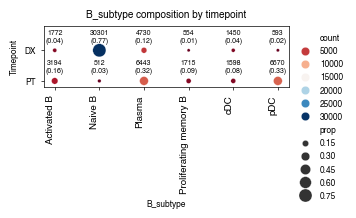

In [27]:
# Draw figure
fig, ax = plt.subplots(figsize=(9/2.54, 5.5/2.54))

ax = sns.scatterplot(
    data=df,
    x="B_subtype", y="timepoint",
    size="prop", sizes=(5, 90),
    hue="count", palette="RdBu",
    ax=ax
)

# y positions
ypos = {cat: i for i, cat in enumerate(df["timepoint"].cat.categories)}

# Label dots
for _, row in df.iterrows():
    y = ypos[row["timepoint"]] + 0.2
    x = row["B_subtype"]
    label = f"{int(row['count'])}\n({row['prop']:.2f})"
    ax.text(
        x, y, label,
        ha="center", va="bottom",
        fontsize=5, color="black", clip_on=False
    )

ax.set_yticks(list(ypos.values()))
ax.set_yticklabels(list(ypos.keys()))
ax.set_title("B_subtype composition by timepoint")
ax.set_xlabel("B_subtype")
ax.set_ylabel("Timepoint")

plt.setp(ax.get_xticklabels(), rotation=90, ha="right")
ax.tick_params(axis="x", labelsize=7)
ax.tick_params(axis="both", width=0.5, length=2)  # thinner tick lines

# Spacing settings
ax.set_ylim(-0.2, 1.8)

# Legend setting
ax.legend(
    bbox_to_anchor=(1, 1),
    loc="upper left",
    frameon=False
)

# Line width settings
for spine in ax.spines.values():
    spine.set_linewidth(0.5)

fig.tight_layout()
fig.savefig(f"{figdir}dotplot_count_timepoint_B.pdf", bbox_inches="tight")
plt.show()


In [ ]:
# Save composition table
df.to_csv(f"{outdir}supp1c_B_composition_counts.csv", index=True)

In [28]:
# Visualize B cell proportion across timepoints for each patient
tbl = (
    adata_B.obs
    .groupby(["sample", "timepoint", "B_subtype"])
    .size()
    .reset_index(name="count")
)

tbl["prop"] = tbl.groupby(["sample", "timepoint"])["count"].transform(lambda x: x / x.sum())

prop_wide = (
    tbl.pivot_table(
        index=["sample", "timepoint"],
        columns="B_subtype",
        values="prop",
        fill_value=0
    )
    .reset_index()
)

prop_wide

/var/folders/b3/wsvv1lxx3xgdznfjpwc1z68h0000gn/T/ipykernel_61744/2720758348.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["sample", "timepoint", "B_subtype"])
/var/folders/b3/wsvv1lxx3xgdznfjpwc1z68h0000gn/T/ipykernel_61744/2720758348.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tbl["prop"] = tbl.groupby(["sample", "timepoint"])["count"].transform(lambda x: x / x.sum())
/var/folders/b3/wsvv1lxx3xgdznfjpwc1z68h0000gn/T/ipykernel_61744/2720758348.py:12: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify 

B_subtype,sample,timepoint,Activated B,Naive B,Plasma,Proliferating memory B,cDC,pDC
0,PAZNRG_DX,DX,0.004879,0.951214,0.005106,0.008282,0.020989,0.009530
1,PAZNRG_PT,PT,0.017422,0.153310,0.233449,0.069686,0.459930,0.066202
2,PAZWZN_DX,DX,0.001575,0.971654,0.012598,0.000000,0.001575,0.012598
3,PAZWZN_PT,PT,0.000000,0.088000,0.016000,0.000000,0.424000,0.472000
4,PBADJC_DX,DX,0.003207,0.965257,0.007483,0.020770,0.003054,0.000229
5,PBADJC_PT,PT,0.000000,0.000000,0.232877,0.000000,0.561644,0.205479
6,PBBCHF_DX,DX,0.237607,0.043503,0.645758,0.025004,0.040613,0.007516
7,PBBCHF_PT,PT,0.165481,0.023462,0.325616,0.087983,0.063431,0.334025
8,PBBKFP_DX,DX,0.004227,0.841184,0.011171,0.003623,0.094907,0.044887
9,PBBKFP_PT,PT,0.003546,0.017730,0.297872,0.000000,0.531915,0.148936


In [29]:
# Save proportion table
prop_wide.to_csv(f"{outdir}fig2d_B_composition_per_timepoint.csv", index=True)

In [49]:
# Save source data for adata_B
umap_df = pd.DataFrame({
    "id": adata_B.obs_names,
    "umap1": adata_B.obsm["X_umap"][:, 0],
    "umap2": adata_B.obsm["X_umap"][:, 1],
    "B_subtype": adata_B.obs["B_subtype"].values
})

umap_df.to_csv(f"{outdir}umap_Bsubtype_source_data_all.csv", index=False)

## Make figures for macrophages

In [50]:
adata_macro = sc.read_h5ad(outdir + 'Macrophage_labeled.h5ad')

In [51]:
# Create mapping dictionary
sample_mapping = {
    'PAZNRG_0DPHBP': 'PAZNRG_PT',
    'PAZNRG_ODNNSP': 'PAZNRG_DX',
    'PBADJC_0DNOML': 'PBADJC_PT',
    'PBADJC_ODNOLY': 'PBADJC_DX',
    'PBBCHF_ODNNA3': 'PBBCHF_PT',
    'PBBCHF_ODNNBG': 'PBBCHF_DX',
}

# Apply the mapping
adata_macro.obs['sample'] = adata_macro.obs['sample'].astype(str).replace(sample_mapping)

# Convert back to categorical if needed
adata_macro.obs['sample'] = adata_macro.obs['sample'].astype('category')

# Verify the changes
print(adata_macro.obs['sample'].unique())


['PAZNRG_PT', 'PAZNRG_DX', 'PAZWZN_DX', 'PAZWZN_PT', 'PBADJC_PT', 'PBADJC_DX', 'PBBCHF_PT', 'PBBCHF_DX', 'PBBKFP_DX', 'PBBKFP_PT']
Categories (10, object): ['PAZNRG_DX', 'PAZNRG_PT', 'PAZWZN_DX', 'PAZWZN_PT', ..., 'PBBCHF_DX', 'PBBCHF_PT', 'PBBKFP_DX', 'PBBKFP_PT']


In [52]:
# Add patient and timepoint metadata
adata_macro.obs['patient'] = adata_macro.obs['sample'].str.replace(r'_(DX|PT)$', '', regex=True)
adata_macro.obs['timepoint'] = adata_macro.obs['sample'].str.extract(r'_(DX|PT)$')[0]

In [ ]:
# Make colored UMAP
fig, ax = plt.subplots(figsize=(9/2.54, 7/2.54))

sc.pl.umap(
    adata_macro,
    color='macro_subtype',
    palette='YlGnBu',
    title='Macrophage Subtypes',
    frameon=False,
    legend_loc='right margin',
    size=2,
    ax=ax,
    show=False
)

fig.savefig(
    f"{figdir}umap_macro_subtype.png",
    dpi=600,
    bbox_inches="tight",
    transparent=True
)

plt.show()

In [ ]:
# Make colored UMAP split by timepoint

for tp in ["DX", "PT"]:
    adata_tp = adata_macro[adata_macro.obs["timepoint"] == tp].copy()

    fig, ax = plt.subplots(figsize=(9/2.54, 7/2.54))

    sc.pl.umap(
        adata_tp,
        color="macro_subtype",
        palette="YlGnBu",
        title=f"Macrophage Subtypes ({tp})",
        frameon=False,
        legend_loc=None,
        size=2,
        ax=ax,
        show=False
    )

    fig.savefig(
        f"{figdir}umap_macro_subtype_{tp}.png",
        dpi=600,
        bbox_inches="tight",
        transparent=True
    )

    plt.show()
    plt.close(fig)

In [ ]:
# Make density plots
# Get coordinates of all cells
X_all = adata_macro.obsm["X_umap"][:, 0]
Y_all = adata_macro.obsm["X_umap"][:, 1]

# Make grid (expanded bounds to prevent contour truncation at edges)
xmin, xmax = X_all.min(), X_all.max()
ymin, ymax = Y_all.min(), Y_all.max()

xrange = xmax - xmin
yrange = ymax - ymin
xpad = 0.10 * xrange
ypad = 0.10 * yrange

xmin_g, xmax_g = xmin - xpad, xmax + xpad
ymin_g, ymax_g = ymin - ypad, ymax + ypad

# Keep full-resolution grid
xx, yy = np.mgrid[xmin_g:xmax_g:200j, ymin_g:ymax_g:200j]
grid = np.vstack([xx.ravel(), yy.ravel()])

# Global KDE using all cells
kde_all = gaussian_kde(np.vstack([X_all, Y_all]))
zz_all = kde_all(grid).reshape(xx.shape)
levels = np.linspace(zz_all.min(), zz_all.max(), 6)


In [ ]:
# Visualize UMAP density contours (no downsampling)
for tp in adata_macro.obs["timepoint"].unique():
    adata_tp = adata_macro[adata_macro.obs["timepoint"] == tp]

    # use all cells in this timepoint
    x = adata_tp.obsm["X_umap"][:, 0]
    y = adata_tp.obsm["X_umap"][:, 1]

    kde_tp = gaussian_kde(np.vstack([x, y]))
    zz_tp = kde_tp(grid).reshape(xx.shape)

    plt.figure(figsize=(6, 4))
    plt.contour(xx, yy, zz_tp, levels=levels, colors="black", linewidths=1)
    plt.title(f"UMAP density contours {tp} (n={adata_tp.n_obs})")
    plt.axis("off")
    plt.savefig(f"{figdir}_umap_density_contours_macro_{tp}.pdf", bbox_inches="tight")
    plt.show()


In [ ]:
# Make dotplot for macrophages
# Set genes to plot
genes_to_plot = [
    'C1QC', 'CD68', 'CCL4', 'F13A1', 'RNASE1', 'HS3ST2', 'CYP27A1', 'IL18', 'IRF8', 'TOP2A', 'MKI67', 'VCAN'
]

In [ ]:
# Make dotplot
dp = sc.pl.dotplot(
    adata_macro,
    genes_to_plot,
    groupby='macro_subtype',
    cmap='YlGnBu',
    return_fig=True,
    show=False,
    standard_scale='var',
)

dp = dp.style(
    smallest_dot=0.01,
    largest_dot=70,
)

# Access axes and style borders
ax_dict = dp.get_axes()

# Make ticks thinner
for _, ax in ax_dict.items():
    if ax is None:
        continue
    ax.tick_params(axis="both", which="both", width=0.5, length=2)

# Main panel border
main_ax = ax_dict.get("mainplot_ax", None)
if main_ax is not None:
    for spine in main_ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.5)
        spine.set_color("#000000")

# Color legend bar border
cax = ax_dict.get("color_legend_ax", None)
if cax is not None:
    for spine in cax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.5)
        spine.set_color("#000000")


# Styling and save
fig = dp.fig
fig.set_size_inches(9/2.54, 6/2.54, forward=True)
fig.tight_layout()
fig.canvas.draw()

display(fig)

fig.savefig(f"{figdir}celltype_dotplot_macro.pdf", bbox_inches="tight")
plt.close(fig)


In [ ]:
# Make proportion dotplot
# Build dataframe
df = (
    adata_macro.obs
    .groupby(["timepoint", "macro_subtype"])
    .size()
    .reset_index(name="count")
)
df["prop"] = df.groupby("timepoint")["count"].transform(lambda x: x / x.sum())

# flip order (PT on top, DX below)
df["timepoint"] = pd.Categorical(df["timepoint"], categories=["PT", "DX"], ordered=True)


In [ ]:
# Draw figure
fig, ax = plt.subplots(figsize=(9/2.54, 5.5/2.54))

ax = sns.scatterplot(
    data=df,
    x="macro_subtype", y="timepoint",
    size="prop", sizes=(5, 90),
    hue="count", palette="RdBu",
    ax=ax
)

# y positions
ypos = {cat: i for i, cat in enumerate(df["timepoint"].cat.categories)}

# Label dots
for _, row in df.iterrows():
    y = ypos[row["timepoint"]] + 0.2
    x = row["macro_subtype"]
    label = f"{int(row['count'])}\n({row['prop']:.2f})"
    ax.text(
        x, y, label,
        ha="center", va="bottom",
        fontsize=5, color="black", clip_on=False
    )

ax.set_yticks(list(ypos.values()))
ax.set_yticklabels(list(ypos.keys()))
ax.set_title("macro_subtype composition by timepoint")
ax.set_xlabel("macro_subtype")
ax.set_ylabel("Timepoint")

plt.setp(ax.get_xticklabels(), rotation=90, ha="right")
ax.tick_params(axis="x", labelsize=7)
ax.tick_params(axis="both", width=0.5, length=2)  # thinner tick lines

# Spacing settings
ax.set_ylim(-0.2, 1.8)

# Legend setting
ax.legend(
    bbox_to_anchor=(1, 1),
    loc="upper left",
    frameon=False
)

# Line width settings
for spine in ax.spines.values():
    spine.set_linewidth(0.5)

fig.tight_layout()
fig.savefig(f"{figdir}dotplot_count_timepoint_macro.pdf", bbox_inches="tight")
plt.show()


In [ ]:
# Save composition table
df.to_csv(f"{outdir}supp1f_macro_composition_counts.csv", index=True)

In [57]:
# Save source data for adata_mac
umap_df = pd.DataFrame({
    "id": adata_macro.obs_names,
    "umap1": adata_macro.obsm["X_umap"][:, 0],
    "umap2": adata_macro.obsm["X_umap"][:, 1],
    "macro_subtype": adata_macro.obs["macro_subtype"].values
})

umap_df.to_csv(f"{outdir}umap_macro_subtype_source_data_all.csv", index=False)

## Make figures for neuroblasts

In [58]:
adata_neuro = sc.read_h5ad(outdir + 'Neuroblast_labeled.h5ad')

In [59]:
# Create mapping dictionary
sample_mapping = {
    'PAZNRG_0DPHBP': 'PAZNRG_PT',
    'PAZNRG_ODNNSP': 'PAZNRG_DX',
    'PBADJC_0DNOML': 'PBADJC_PT',
    'PBADJC_ODNOLY': 'PBADJC_DX',
    'PBBCHF_ODNNA3': 'PBBCHF_PT',
    'PBBCHF_ODNNBG': 'PBBCHF_DX',
}

# Apply the mapping
adata_neuro.obs['sample'] = adata_neuro.obs['sample'].astype(str).replace(sample_mapping)

# Convert back to categorical if needed
adata_neuro.obs['sample'] = adata_neuro.obs['sample'].astype('category')

# Verify the changes
print(adata_neuro.obs['sample'].unique())


['PAZNRG_PT', 'PAZNRG_DX', 'PAZWZN_DX', 'PAZWZN_PT', 'PBADJC_PT', 'PBADJC_DX', 'PBBCHF_PT', 'PBBCHF_DX', 'PBBKFP_DX', 'PBBKFP_PT']
Categories (10, object): ['PAZNRG_DX', 'PAZNRG_PT', 'PAZWZN_DX', 'PAZWZN_PT', ..., 'PBBCHF_DX', 'PBBCHF_PT', 'PBBKFP_DX', 'PBBKFP_PT']


In [60]:
# Add patient and timepoint metadata
adata_neuro.obs['patient'] = adata_neuro.obs['sample'].str.replace(r'_(DX|PT)$', '', regex=True)
adata_neuro.obs['timepoint'] = adata_neuro.obs['sample'].str.extract(r'_(DX|PT)$')[0]

In [ ]:
# Make colored UMAP
fig, ax = plt.subplots(figsize=(9/2.54, 7/2.54))

sc.pl.umap(
    adata_neuro,
    color='neuro_subtype',
    palette='YlGnBu',
    title='Neuroblast Subtypes',
    frameon=False,
    legend_loc='right margin',
    size=2,
    ax=ax,
    show=False
)

fig.savefig(
    f"{figdir}umap_neuro_subtype.png",
    dpi=600,
    bbox_inches="tight",
    transparent=True
)

plt.show()


In [ ]:
# Make colored UMAP split by timepoint

for tp in ["DX", "PT"]:
    adata_tp = adata_neuro[adata_neuro.obs["timepoint"] == tp].copy()

    fig, ax = plt.subplots(figsize=(9/2.54, 7/2.54))

    sc.pl.umap(
        adata_tp,
        color="neuro_subtype",
        palette="YlGnBu",
        title=f"Neuroblast Subtypes ({tp})",
        frameon=False,
        legend_loc=None,
        size=2,
        ax=ax,
        show=False
    )

    fig.savefig(
        f"{figdir}umap_neuro_subtype_{tp}.png",
        dpi=600,
        bbox_inches="tight",
        transparent=True
    )

    plt.show()
    plt.close(fig)


In [ ]:
# Make density plots
# Get coordinates of all cells
X_all = adata_neuro.obsm["X_umap"][:, 0]
Y_all = adata_neuro.obsm["X_umap"][:, 1]

# Make grid (expanded bounds to prevent contour truncation at edges)
xmin, xmax = X_all.min(), X_all.max()
ymin, ymax = Y_all.min(), Y_all.max()

xrange = xmax - xmin
yrange = ymax - ymin
xpad = 0.10 * xrange
ypad = 0.10 * yrange

xmin_g, xmax_g = xmin - xpad, xmax + xpad
ymin_g, ymax_g = ymin - ypad, ymax + ypad

# Keep full-resolution grid
xx, yy = np.mgrid[xmin_g:xmax_g:200j, ymin_g:ymax_g:200j]
grid = np.vstack([xx.ravel(), yy.ravel()])

# Global KDE using all cells
kde_all = gaussian_kde(np.vstack([X_all, Y_all]))
zz_all = kde_all(grid).reshape(xx.shape)
levels = np.linspace(zz_all.min(), zz_all.max(), 6)

In [ ]:
# Visualize UMAP density contours (no downsampling)
for tp in adata_neuro.obs["timepoint"].unique():
    adata_tp = adata_neuro[adata_neuro.obs["timepoint"] == tp]

    # use all cells in this timepoint
    x = adata_tp.obsm["X_umap"][:, 0]
    y = adata_tp.obsm["X_umap"][:, 1]

    kde_tp = gaussian_kde(np.vstack([x, y]))
    zz_tp = kde_tp(grid).reshape(xx.shape)

    plt.figure(figsize=(6, 4))
    plt.contour(xx, yy, zz_tp, levels=levels, colors="black", linewidths=1)
    plt.title(f"UMAP density contours {tp} (n={adata_tp.n_obs})")
    plt.axis("off")
    plt.savefig(f"{figdir}_umap_density_contours_neuro_{tp}.pdf", bbox_inches="tight")
    plt.show()


In [ ]:
# Make dotplot for neuroblasts
# Set genes to plot
genes_to_plot = [
    'KCNQ3', 'FMN1', 'PPP2R2C', 'PHOX2B', 'HAND2', 'TH', 'DBH', 'GCH1', 'MKI67', 'TOP2A',
    'EZH2', 'BEX1', 'NCAM1', 'MYCN', 'COL1A1', 'COL4A1'
]

In [ ]:
# Make dotplot
dp = sc.pl.dotplot(
    adata_neuro,
    genes_to_plot,
    groupby='neuro_subtype',
    cmap='YlGnBu',
    return_fig=True,
    show=False,
    standard_scale='var',
)

dp = dp.style(
    smallest_dot=0.01,
    largest_dot=70,
)

# Access axes and style borders
ax_dict = dp.get_axes()

# Make ticks thinner
for _, ax in ax_dict.items():
    if ax is None:
        continue
    ax.tick_params(axis="both", which="both", width=0.5, length=2)

# Main panel border
main_ax = ax_dict.get("mainplot_ax", None)
if main_ax is not None:
    for spine in main_ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.5)
        spine.set_color("#000000")

# Color legend bar border
cax = ax_dict.get("color_legend_ax", None)
if cax is not None:
    for spine in cax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.5)
        spine.set_color("#000000")


# Styling and save
fig = dp.fig
fig.set_size_inches(9/2.54, 4/2.54, forward=True)
fig.tight_layout()
fig.canvas.draw()

display(fig)

fig.savefig(f"{figdir}celltype_dotplot_neuro.pdf", bbox_inches="tight")
plt.close(fig)

In [ ]:
# Make proportion dotplot
# Build dataframe
df = (
    adata_neuro.obs
    .groupby(["timepoint", "neuro_subtype"])
    .size()
    .reset_index(name="count")
)
df["prop"] = df.groupby("timepoint")["count"].transform(lambda x: x / x.sum())

# flip order (PT on top, DX below)
df["timepoint"] = pd.Categorical(df["timepoint"], categories=["PT", "DX"], ordered=True)

In [ ]:
# Draw figure
fig, ax = plt.subplots(figsize=(9/2.54, 5.5/2.54))

ax = sns.scatterplot(
    data=df,
    x="neuro_subtype", y="timepoint",
    size="prop", sizes=(5, 90),
    hue="count", palette="RdBu",
    ax=ax
)

# y positions
ypos = {cat: i for i, cat in enumerate(df["timepoint"].cat.categories)}

# Label dots
for _, row in df.iterrows():
    y = ypos[row["timepoint"]] + 0.2
    x = row["neuro_subtype"]
    label = f"{int(row['count'])}\n({row['prop']:.2f})"
    ax.text(
        x, y, label,
        ha="center", va="bottom",
        fontsize=5, color="black", clip_on=False
    )

ax.set_yticks(list(ypos.values()))
ax.set_yticklabels(list(ypos.keys()))
ax.set_title("neuro_subtype composition by timepoint")
ax.set_xlabel("neuro_subtype")
ax.set_ylabel("Timepoint")

plt.setp(ax.get_xticklabels(), rotation=90, ha="right")
ax.tick_params(axis="x", labelsize=7)
ax.tick_params(axis="both", width=0.5, length=2)  # thinner tick lines

# Spacing settings
ax.set_ylim(-0.2, 1.8)

# Legend setting
ax.legend(
    bbox_to_anchor=(1, 1),
    loc="upper left",
    frameon=False
)

# Line width settings
for spine in ax.spines.values():
    spine.set_linewidth(0.5)

fig.tight_layout()
fig.savefig(f"{figdir}dotplot_count_timepoint_neuro.pdf", bbox_inches="tight")
plt.show()


In [ ]:
# Save composition table
df.to_csv(f"{outdir}supp1i_neuro_composition_counts.csv", index=True)

In [62]:
# Save source data for adata_neuro (split into 2; first gets +1 row if odd)
umap_df = pd.DataFrame({
    "id": adata_neuro.obs_names,
    "umap1": adata_neuro.obsm["X_umap"][:, 0],
    "umap2": adata_neuro.obsm["X_umap"][:, 1],
    "neuro_subtype": adata_neuro.obs["neuro_subtype"].values
})

n = len(umap_df)
first_n = (n + 1) // 2  # first file gets extra row when n is odd

umap_df.iloc[:first_n].to_csv(f"{outdir}umap_neuro_subtype_source_data_part1.csv", index=False)
umap_df.iloc[first_n:].to_csv(f"{outdir}umap_neuro_subtype_source_data_part2.csv", index=False)

## Export cell ID and color for Xenium Explorer 4.1
Snippet for interested sample(s) only

In [ ]:
# Get sample
sample_id = "PBBCHF_DX"
sub = adata[adata.obs["sample"] == sample_id].copy()

# Build color map for celltype
if "celltype_colors" in adata.uns and pd.api.types.is_categorical_dtype(adata.obs["celltype"]):
    cats = adata.obs["celltype"].cat.categories
    colors = adata.uns["celltype_colors"]
    celltype_color_map = {c: colors[i] for i, c in enumerate(cats)}
else:
    celltype_color_map = {c: "#E6E6E6" for c in pd.unique(adata.obs["celltype"])}

df_out = pd.DataFrame({
    "cell_id": sub.obs["cell_id"].values,
    "group": sub.obs["celltypes_all"].values,
    "color": sub.obs["celltype"].map(celltype_color_map).values
})

# Save
df_out.to_csv(f"{outdir}{sample_id}_celltypes_colors.csv", index=False)